# 02 — CBAM Attention Integration

This notebook adds CBAM (Convolutional Block Attention Module) to the baseline YOLOv8n model and fine-tunes it. CBAM amplifies feature responses from small aerial objects while suppressing background noise.

**CBAM Architecture:**
1. **Channel Attention** — answers "what to focus on" by reweighting feature channels
2. **Spatial Attention** — answers "where to focus" by highlighting spatial regions

The goal is to measure the mAP improvement from CBAM over the baseline.

## Install Dependencies and Mount Drive

In [1]:
!pip install ultralytics matplotlib -q

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

candidate_paths = [
    Path('/content/drive/MyDrive/uav-small-object-detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector/UAV_small_obj_detector'),
    Path('/content/drive/MyDrive/UAV_small_obj_detector'),
]

project_root = next((path for path in candidate_paths if path.exists()), None)
if project_root is None:
    raise FileNotFoundError(
        'Could not find the project folder in Google Drive. '
        'Check MyDrive/uav-small-object-detector and MyDrive/UAV_small_obj_detector.'
    )

os.chdir(project_root)
print(f'Working directory: {project_root}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.6 MB/s eta 0:00:00
Mounted at /content/drive
Working directory: /content/drive/MyDrive/UAV_small_obj_detector


## Load CBAM Module

In [2]:
import sys
sys.path.insert(0, '.')
from src.cbam import CBAM
import torch

print("CBAM module loaded successfully.")

CBAM module loaded successfully.


## Load Baseline Trained Weights

In [3]:
from ultralytics import YOLO

# Load the model trained in Notebook 01
model = YOLO('runs/detect/baseline_visdrone2/weights/best.pt')
print("Baseline weights loaded.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Baseline weights loaded.


## Inspect Model Architecture to Find Correct Hook Layer

In [4]:
# Print model architecture to identify the target layer for CBAM hook
for i, layer in enumerate(model.model.model):
    print(f"Layer {i}: {type(layer).__name__}")

Layer 0: Conv
Layer 1: Conv
Layer 2: C2f
Layer 3: Conv
Layer 4: C2f
Layer 5: Conv
Layer 6: C2f
Layer 7: Conv
Layer 8: C2f
Layer 9: SPPF
Layer 10: Upsample
Layer 11: Concat
Layer 12: C2f
Layer 13: Upsample
Layer 14: Concat
Layer 15: C2f
Layer 16: Conv
Layer 17: Concat
Layer 18: C2f
Layer 19: Conv
Layer 20: Concat
Layer 21: C2f
Layer 22: Detect


## Probe Layer Output Shape Before Attaching CBAM

In [5]:
# We need to know the output channels of the target layer to initialize CBAM correctly.
# The last C2f backbone block is typically around layer 9 or 10.

target_idx = 9  # Adjust based on the output above

class ShapeProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.shape = None
    def forward(self, x):
        self.shape = x.shape
        return x

probe = ShapeProbe()
hook = model.model.model[target_idx].register_forward_hook(
    lambda m, inp, out: probe(out)
)

# Run a dummy forward pass
import torch
dummy = torch.zeros(1, 3, 640, 640)
_ = model.model(dummy)

print(f"Target layer {target_idx} output shape: {probe.shape}")
hook.remove()

Target layer 9 output shape: torch.Size([1, 256, 20, 20])


In [7]:
from pathlib import Path
import os
import shutil
from PIL import Image
from ultralytics.utils.downloads import download

dataset_root = Path('/content/VisDrone')

def visdrone2yolo(root, split, source_name):
    source_dir = root / source_name
    images_dir = root / 'images' / split
    labels_dir = root / 'labels' / split
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    for img in (source_dir / 'images').glob('*.jpg'):
        shutil.move(str(img), str(images_dir / img.name))

    for ann in (source_dir / 'annotations').glob('*.txt'):
        img_path = images_dir / ann.with_suffix('.jpg').name
        img_w, img_h = Image.open(img_path).size
        dw, dh = 1.0 / img_w, 1.0 / img_h
        lines = []

        with open(ann, encoding='utf-8') as f:
            for row in [x.split(',') for x in f.read().strip().splitlines()]:
                if row[4] != '0':
                    x, y, w, h = map(int, row[:4])
                    cls = int(row[5]) - 1
                    x_center = (x + w / 2) * dw
                    y_center = (y + h / 2) * dh
                    w_norm = w * dw
                    h_norm = h * dh
                    lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n')

        with open(labels_dir / ann.name, 'w', encoding='utf-8') as out:
            out.writelines(lines)

if not (dataset_root / 'images' / 'val').exists():
    urls = [
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip',
    ]
    download(urls, dir=dataset_root, threads=4)

    for folder, split in {
        'VisDrone2019-DET-train': 'train',
        'VisDrone2019-DET-val': 'val',
        'VisDrone2019-DET-test-dev': 'test',
    }.items():
        visdrone2yolo(dataset_root, split, folder)
        shutil.rmtree(dataset_root / folder)

print("Train images:", len(os.listdir('/content/VisDrone/images/train')))
print("Val images:", len(os.listdir('/content/VisDrone/images/val')))


Unzipping /content/VisDrone/VisDrone2019-DET-val.zip to /content/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 195.9files/s 5.6s
Unzipping /content/VisDrone/VisDrone2019-DET-test-dev.zip to /content/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 540.4files/s 6.0s
Unzipping /content/VisDrone/VisDrone2019-DET-train.zip to /content/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.4Kfiles/s 9.1s
Train images: 6471
Val images: 548


## Attach CBAM as a Forward Hook and Fine-Tune

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Use the probed channel count for CBAM initialization
in_channels = probe.shape[1]
cbam = CBAM(in_channels=in_channels).to(device)
print(f"CBAM initialized with {in_channels} channels on {device}")

def cbam_hook(module, input, output):
    return cbam(output)

# Register the forward hook on the target layer
hook = model.model.model[target_idx].register_forward_hook(cbam_hook)
print(f"CBAM hook registered on layer {target_idx}")

# Fine-tune for 10 more epochs with CBAM active
model.train(
    data='visdrone.yaml',
    epochs=10,
    name='cbam_visdrone',
    save_period=5
)

# Remove the hook after training
hook.remove()
print("CBAM hook removed. Training complete.")

CBAM initialized with 256 channels on cuda
CBAM hook registered on layer 9
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/baseline_visdrone2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cbam_visdrone2, nbs

## Evaluate CBAM-Enhanced Model

In [9]:
cbam_metrics = model.val()
cbam_map50 = float(cbam_metrics.box.map50)
cbam_map50_95 = float(cbam_metrics.box.map)
print(f"CBAM mAP@50:    {cbam_map50:.4f}")
print(f"CBAM mAP@50-95: {cbam_map50_95:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2137.6±1056.3 MB/s, size: 153.1 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 229.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.8it/s 12.4s
                   all        548      38759      0.415      0.302      0.302      0.173
            pedestrian        520       8844      0.385      0.342      0.318      0.131
                people        482       5125      0.445      0.236      0.251      0.087
               bicycle        364       1287      0.193     0.0867     0.0592     0.0214
                   car        515      14064      0.598      0.731      0.728      0.488
                   van        421       1975  

## Save CBAM Metrics to JSON

In [10]:
import json

with open('results/metrics.json', 'r') as f:
    all_metrics = json.load(f)

all_metrics["cbam"] = {
    "mAP50": cbam_map50,
    "mAP50-95": cbam_map50_95,
    "precision": float(cbam_metrics.box.mp),
    "recall": float(cbam_metrics.box.mr)
}

with open('results/metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print("CBAM metrics saved.")
print(json.dumps(all_metrics, indent=2))

CBAM metrics saved.
{
  "baseline": {
    "mAP50": 0.29373669317784457,
    "mAP50-95": 0.1662671086264691,
    "precision": 0.39159907325051424,
    "recall": 0.30258304542539205
  },
  "cbam": {
    "mAP50": 0.30206881342972747,
    "mAP50-95": 0.17270067683582924,
    "precision": 0.414643359389183,
    "recall": 0.3024832252138724
  }
}


## Generate Baseline vs CBAM Comparison Chart

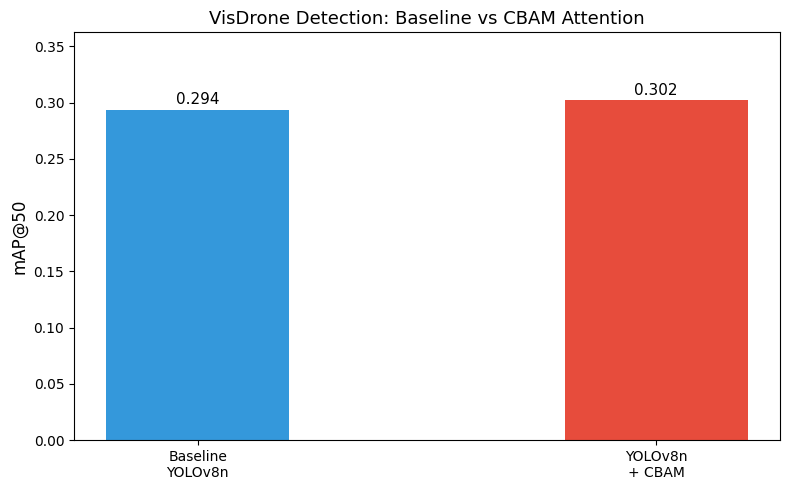

Chart saved to results/cbam_comparison.png


In [11]:
import matplotlib.pyplot as plt

# Load baseline mAP50
baseline_map50 = all_metrics["baseline"]["mAP50"]

models = ['Baseline\nYOLOv8n', 'YOLOv8n\n+ CBAM']
map50 = [baseline_map50, cbam_map50]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, map50, color=['#3498db', '#e74c3c'], width=0.4)
plt.ylabel('mAP@50', fontsize=12)
plt.title('VisDrone Detection: Baseline vs CBAM Attention', fontsize=13)
plt.ylim(0, max(map50) * 1.2)
for bar, v in zip(bars, map50):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('results/cbam_comparison.png', dpi=150)
plt.show()

print(f"Chart saved to results/cbam_comparison.png")

## Results Summary

**CBAM Attention Impact**

| Model | mAP@50 | Change |
|---|---|---|
| Baseline YOLOv8n | 0.294 | - |
| YOLOv8n + CBAM | 0.302 | +0.008 |

**Next step:** Open `03_gradcam_viz.ipynb` to generate attention heatmaps.

In [12]:
!find /content/drive/MyDrive -path "*cbam*best.pt"


/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/cbam_visdrone2/weights/best.pt


In [13]:
metrics = model.val(data='visdrone.yaml')

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("precision:", metrics.box.mp)
print("recall:", metrics.box.mr)


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2625.0±900.3 MB/s, size: 98.7 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 229.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.0it/s 11.8s
                   all        548      38759      0.415      0.302      0.302      0.173
            pedestrian        520       8844      0.385      0.342      0.318      0.131
                people        482       5125      0.445      0.236      0.251      0.087
               bicycle        364       1287      0.193     0.0867     0.0592     0.0214
                   car        515      14064      0.598      0.731      0.728      0.488
                   van        421       1975      0.446      0.314      0.328      0.226
                 truck        266      

In [14]:
baseline_map50 = 0.29373669317784457
baseline_map = 0.1662671086264691

cbam_map50 = metrics.box.map50
cbam_map = metrics.box.map

print("mAP50 improvement:", cbam_map50 - baseline_map50)
print("mAP50-95 improvement:", cbam_map - baseline_map)


mAP50 improvement: 0.008332120251882902
mAP50-95 improvement: 0.006433568209360141


In [15]:
!find /content/drive/MyDrive -path "*cbam*best.pt"


/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/cbam_visdrone2/weights/best.pt
